In [18]:
import os
import json
import random
import time
from mistralai import Mistral

In [19]:
# save a single document from filtered_output.json
doc_name = "1535602.xml"
topic = "LärmMietminderung"
new_doc_path = f"Data/clean/{topic}.json"
all_docs = json.load(open("Data/clean/filtered_output.json", "r", encoding="utf-8"))

if doc_name in all_docs:
    doc = all_docs[doc_name]
else:
    print(f"{doc_name} nicht gefunden.")

# save the document to a file
with open(new_doc_path, "w", encoding="utf-8") as f:
    json.dump(doc, f, indent=4, ensure_ascii=False)


In [20]:
input_path_doc = "Data/clean/LärmMietminderung.json"
input_path_onto = "ontology_output/gcq_ontology_topdown_refined_with_keywords.json"
output_path = ""

api_key = "ujI60UR6Fe5jel48SAtfnMiN5Skxfwhq"
model = "open-mistral-nemo"
client = Mistral(api_key=api_key)
SEED = 69
TEMPERATURE = 0.69
random.seed(SEED)

role = "You are an expert legal knowledge engineer."
goal = "Building an knowledge-graph on the given ontology for the analysis of legal issues."


In [21]:
def build_user_prompt(goal, ontology, uploaded_doc, question):
    return f"""
        Your goal is: {goal}

        To do that you should populate the following ontology using the information extracted from a legal document.

        The ontology is represented in JSON format. It contains a set of triplets (Class-Property-Class).
        Your should extract relevant entities from the document and add them as instances, following the structure of the ontology.

        Please respect the schema strictly. Use the class names and property names as defined in the ontology. Do not invent new classes or properties. If no suitable instance can be found for a certain class or property, leave it empty.

        --- ONTOLOGY ---
        {ontology}

        --- LEGAL DOCUMENT ---
        {uploaded_doc}

        --- INSTRUCTIONS ---
        Based on the document above, populate the ontology with appropriate instances.
        Return only the filled JSON ontology, following the original schema. Do not add explanations or additional text. Make sure the populated instances are logically consistent and legally accurate.
        It would be great, if you could look, if the ontology could answer the following question: {question}
        If the ontology cannot answer the question, please add a new class or property but extend their name with "new_class" or "new_property" respectively. I.e. if "Mietkaution" ould be new its name should be "Mietkaution_new_class".
        Only return the JSON representation of the ontology, without any additional text or explanations.
        --- END OF INSTRUCTIONS ---

        If applicable, please use the following constraints:
        - Use full names whenever possible.
        - Use the most specific class available in the ontology.
        """



In [22]:
def call_mistral(prompt):
    response = client.chat.complete(
        model=model,
        random_seed=SEED,
        messages=[
            {"role": "system", "content": role},
            {"role": "user", "content": prompt}
        ],
        temperature=TEMPERATURE,
    )
    
    return response.choices[0].message.content.strip()

In [23]:
with open("ontology_output/gcq_ontology_topdown_small.json", "r", encoding="utf-8") as f:
    ontologys = json.load(f)

ontology = ontologys.get("Cluster 8", {}).get("ontology")

with open(input_path_onto, "w", encoding="utf-8") as f:
    json.dump(ontology, f, indent=4, ensure_ascii=False)

In [30]:
with open(input_path_doc, "r", encoding="utf-8") as f:
    document = json.load(f)

with open(input_path_onto, "r", encoding="utf-8") as f:
    ontology = json.load(f)

question = "Wann darf ich eine Mietminderung wegen Lärm durchführen?"
prompt = build_user_prompt(goal, ontology, document, question)

response = json.loads(call_mistral(prompt))


In [31]:
with open("ontology_output/knowledge_graph/miete_v2.json", "w", encoding="utf-8") as f:
    json.dump(response, f, indent=4, ensure_ascii=False)

C:\Users\fabia\AppData\Local\Temp\ipykernel_10116\877028747.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


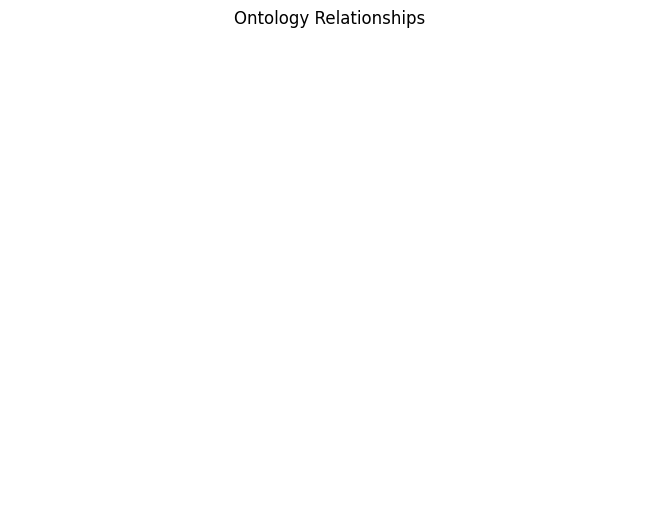

In [32]:
#Visualize
import matplotlib.pyplot as plt
import networkx as nx

relationships = response.get("relationships", [])

# Create a directed graph
G = nx.DiGraph()

# Add edges with labels
for subj, pred, obj in relationships:
    G.add_edge(subj, obj, label=pred)

# Draw the graph
pos = nx.spring_layout(G, seed=42)  # Layout for consistent positioning

# Draw nodes and edges
nx.draw(G, pos, with_labels=True, node_size=3000, node_color="lightblue", font_size=10, font_weight='bold', arrows=True)

# Draw edge labels
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red')

# Show the plot
plt.title("Ontology Relationships")
plt.axis("off")
plt.tight_layout()
plt.show()
